In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_deepseek import ChatDeepSeek
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
api_key = os.getenv("DEEPSEEK_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = "subgraphs"

# Separate state sub-graph

In [30]:
# substate
class SubState(TypedDict):
    input_text: str
    translated_text: str

# node
def sub_chat_node(state: SubState):
    chat_model = ChatDeepSeek(api_key=api_key, model="deepseek-v4-flash")
    prompt_template = PromptTemplate.from_template(
        """
            Given user text, translate it to 500 words hindi essay.
            Do not generate new content. Just translate the text.

            text:
            {text}
        """
    )
    parser = StrOutputParser()
    chain = prompt_template | chat_model | parser
    response = chain.invoke(input={"text": state["input_text"]})
    return {"translated_text": response}

# subgraph
subgraph = StateGraph(SubState)
subgraph.add_node("chat_node", sub_chat_node)
subgraph.add_edge(START, "chat_node")
subgraph.add_edge("chat_node", END)
sub_workflow = subgraph.compile()

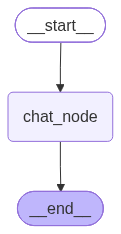

In [33]:
sub_workflow

In [32]:
# state
class LangState(TypedDict):
    topic: str
    english_essay: str
    hindi_essay: str

# nodes
def chat_node(state: LangState):
    chat_model = ChatDeepSeek(api_key=api_key, model="deepseek-v4-flash")
    prompt_template = PromptTemplate.from_template(
        """
            Given user topic, write 500 words english essay.

            topic:
            {topic}
        """
    )
    parser = StrOutputParser()
    chain = prompt_template | chat_model | parser
    response = chain.invoke(input={"topic": state["topic"]})
    return {"english_essay": response}

def translate_node(state: LangState):
    response_state = sub_workflow.invoke(input={"input_text": state["english_essay"]})
    return {"hindi_essay": response_state["translated_text"]}

# graph
graph = StateGraph(LangState)
graph.add_node("chat_node", chat_node)
graph.add_node("translate_node", translate_node)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", "translate_node")
graph.add_edge("translate_node", END)
workflow = graph.compile()

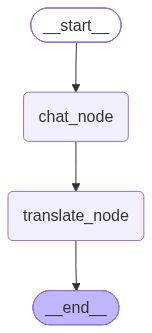

In [34]:
workflow

In [35]:
# invoke graph
initial_state = {"topic": "AI Takeover"}
response_state = workflow.invoke(input=initial_state)

In [36]:
print(response_state["topic"])
print("-"*60)
print(response_state["english_essay"])
print("-"*60)
print(response_state["hindi_essay"])

AI Takeover
------------------------------------------------------------
# AI Takeover: A Future We Must Shape

The phrase “AI takeover” evokes dystopian images of sentient machines subjugating humanity. Yet the reality of artificial intelligence’s ascendancy is more nuanced. AI is already taking over—not through malevolent consciousness, but through its quiet integration into every facet of modern life. It curates our news, drives our investments, diagnoses our diseases, and decides what we see. The question is not whether AI will take over, but how we choose to manage its growing power.

The most immediate concern is economic displacement. Automation has already replaced countless routine jobs, from factory floor workers to data-entry clerks. As large language models and robotics advance, white-collar professions—law, journalism, customer service—face disruption. This transition could exacerbate inequality, concentrating wealth in the hands of those who own AI systems. However, takeo

# Same state sub-graph

In [2]:
# Shared State
class ParentState(TypedDict):
    topic: str
    english_essay: str
    hindi_essay: str

In [6]:
# sub workflow code

# node
def sub_chat_node(state: ParentState):
    chat_model = ChatDeepSeek(api_key=api_key, model="deepseek-v4-flash")
    prompt_template = PromptTemplate.from_template(
        """
            Given user text, translate it to 500 words hindi essay.
            Do not generate new content. Just translate the text.

            text:
            {text}
        """
    )
    parser = StrOutputParser()
    chain = prompt_template | chat_model | parser
    response = chain.invoke(input={"text": state["english_essay"]})
    return {"hindi_essay": response}

# subgraph
subgraph = StateGraph(ParentState)
subgraph.add_node("chat_node", sub_chat_node)
subgraph.add_edge(START, "chat_node")
subgraph.add_edge("chat_node", END)
sub_workflow = subgraph.compile()

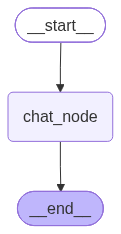

In [7]:
sub_workflow

In [8]:
# parent workflow code

# nodes
def chat_node(state: ParentState):
    chat_model = ChatDeepSeek(api_key=api_key, model="deepseek-v4-flash")
    prompt_template = PromptTemplate.from_template(
        """
            Given user topic, write 500 words english essay.

            topic:
            {topic}
        """
    )
    parser = StrOutputParser()
    chain = prompt_template | chat_model | parser
    response = chain.invoke(input={"topic": state["topic"]})
    return {"english_essay": response}


# graph
graph = StateGraph(ParentState)
graph.add_node("chat_node", chat_node)
graph.add_node("translate_node", sub_workflow)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", "translate_node")
graph.add_edge("translate_node", END)
workflow = graph.compile()

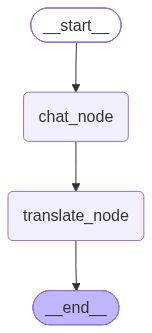

In [9]:
workflow

In [10]:
# invoke graph
initial_state = {"topic": "Iceage in future"}
response_state = workflow.invoke(input=initial_state)

In [11]:
print(response_state["topic"])
print("-"*60)
print(response_state["english_essay"])
print("-"*60)
print(response_state["hindi_essay"])

Iceage in future
------------------------------------------------------------
### The Coming Ice Age: A Paradox of Climate

The idea of a future ice age seems almost absurd in an era defined by record-breaking heat, melting glaciers, and rising sea levels. Yet for most of Earth’s history, the planet has been far colder than it is today. Ice ages have occurred with rhythmic regularity, and the only question is not whether another will come, but when—and how human activity might alter that timetable.

Natural ice ages are driven primarily by Milankovitch cycles: slow variations in Earth’s orbit, axial tilt, and wobble. These cycles change the distribution and intensity of sunlight reaching high northern latitudes. When summers in the Arctic grow cool enough, winter snow survives year-round, building glaciers that eventually spread into vast ice sheets. This orbital pacemaker has produced roughly nine glacial–interglacial cycles over the past million years, each lasting about a hundred th